# 🐟 Fish Species Detection — YOLOv8s (StockFish Dataset)

This notebook trains a **YOLOv8 Small** model to detect and classify fish species.

**5 Species in dataset:**
| ID | Species |
|----|---------|
| 0 | Catla |
| 1 | CommonCarp |
| 2 | Mori |
| 3 | Rohu |
| 4 | SilverCarp |

---
## ⚠️ Before Running — Enable GPU
1. Click **Runtime** → **Change runtime type**
2. Set **Hardware accelerator** to **GPU (T4)**
3. Click **Save**, then run cells top to bottom

In [1]:
# ─────────────────────────────────────────────
# CELL 1 — Check GPU
# ─────────────────────────────────────────────
import subprocess

result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print('✅ GPU is available!')
    print(result.stdout)
else:
    print('❌ No GPU detected. Please enable GPU in Runtime > Change runtime type.')

import torch
print(f'PyTorch CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU Device: {torch.cuda.get_device_name(0)}')

✅ GPU is available!
Mon Mar 16 10:45:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------------

In [2]:
# ─────────────────────────────────────────────
# CELL 2 — Install Libraries
# ─────────────────────────────────────────────
!pip install ultralytics --quiet
!pip install tensorflow --quiet
!pip install keras --quiet
!pip install numpy --quiet
!pip install opencv-python --quiet
!pip install matplotlib --quiet
!pip install Pillow --quiet
!pip install scikit-learn --quiet
!pip install pyyaml --quiet
print('✅ All libraries installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.3 MB/s eta 0:00:00
✅ All libraries installed!


In [3]:
# ─────────────────────────────────────────────
# CELL 3 — Verify Imports
# ─────────────────────────────────────────────
import ultralytics
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import sklearn
import os

print(f'Ultralytics version : {ultralytics.__version__}')
print(f'TensorFlow version  : {tf.__version__}')
print(f'NumPy version       : {np.__version__}')
print(f'OpenCV version      : {cv2.__version__}')
print(f'Scikit-learn version: {sklearn.__version__}')
print('\n✅ All imports successful!')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version : 8.4.22
TensorFlow version  : 2.19.0
NumPy version       : 2.0.2
OpenCV version      : 4.13.0
Scikit-learn version: 1.6.1

✅ All imports successful!


In [4]:
# ─────────────────────────────────────────────
# CELL 4 — Create Directory Structure
# ─────────────────────────────────────────────
import os

BASE_DIR      = '/content/fish_project'
YOLO_DATA_DIR = os.path.join(BASE_DIR, 'yolo_dataset')
DISEASE_DIR   = os.path.join(BASE_DIR, 'disease_dataset')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')

for d in [BASE_DIR, YOLO_DATA_DIR, DISEASE_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print('📁 Directory structure created:')
print(f'  {BASE_DIR}/')
print(f'  ├── yolo_dataset/')
print(f'  ├── disease_dataset/')
print(f'  └── models/')

📁 Directory structure created:
  /content/fish_project/
  ├── yolo_dataset/
  ├── disease_dataset/
  └── models/


In [5]:
# ─────────────────────────────────────────────
# CELL 5 — Mount Google Drive
# ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted.')

Mounted at /content/drive
✅ Google Drive mounted.


In [6]:
# ─────────────────────────────────────────────
# CELL 6 — Upload & Extract StockFish Dataset
# ─────────────────────────────────────────────
# Your ZIP is stored in Google Drive root as StockFish-1.zip
# If the filename is different, update UPLOADED_ZIP below.

import zipfile, os

UPLOADED_ZIP = '/content/drive/MyDrive/fish fish/StockFish-1.zip'

print(f'📦 Extracting {UPLOADED_ZIP} ...')
with zipfile.ZipFile(UPLOADED_ZIP, 'r') as zf:
    zf.extractall(YOLO_DATA_DIR)
print(f'✅ Extracted to: {YOLO_DATA_DIR}')

# ── Auto-detect the dataset root inside the ZIP ──────────────
# The ZIP may contain a subfolder (e.g. StockFish-1/) or extract flat.
# This block finds the folder that contains data.yaml automatically.
DATASET_ROOT = None
for root, dirs, files in os.walk(YOLO_DATA_DIR):
    if 'data.yaml' in files:
        DATASET_ROOT = root
        break

if DATASET_ROOT is None:
    raise FileNotFoundError(
        'data.yaml not found inside the ZIP. '
        'Make sure your ZIP contains a YOLO-format dataset with data.yaml.'
    )

YOLO_DATASET_YAML = os.path.join(DATASET_ROOT, 'data.yaml')
print(f'📄 data.yaml found at: {YOLO_DATASET_YAML}')

📦 Extracting /content/drive/MyDrive/fish fish/StockFish-1.zip ...
✅ Extracted to: /content/fish_project/yolo_dataset
📄 data.yaml found at: /content/fish_project/yolo_dataset/StockFish-1/data.yaml


In [7]:
# ─────────────────────────────────────────────
# CELL 7 — Fix data.yaml (path + nc)
# ─────────────────────────────────────────────
# Fixes TWO known problems with the StockFish data.yaml:
#   1. 'path' field is missing or wrong → YOLO can't find images
#   2. 'nc' field is None              → YOLO doesn't know class count

import yaml

with open(YOLO_DATASET_YAML, 'r') as f:
    data = yaml.safe_load(f)

print('📄 Original data.yaml contents:')
for k, v in data.items():
    print(f'   {k}: {v}')

# Fix 1: Set the absolute path to the dataset root
data['path'] = DATASET_ROOT

# Fix 2: Make sure nc (num classes) matches the actual names list
if isinstance(data.get('names'), dict):
    # Convert dict format {0: 'Catla', 1: 'Rohu', ...} to list
    names_list = [data['names'][i] for i in sorted(data['names'].keys())]
    data['names'] = names_list

data['nc'] = len(data['names'])   # Always set nc from actual names

with open(YOLO_DATASET_YAML, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print('\n📄 Fixed data.yaml contents:')
for k, v in data.items():
    print(f'   {k}: {v}')

# Store class names for use throughout the notebook
CLASS_NAMES_YOLO = data['names']
NUM_CLASSES      = data['nc']

print(f'\n✅ data.yaml fixed.')
print(f'   Classes ({NUM_CLASSES}): {CLASS_NAMES_YOLO}')

📄 Original data.yaml contents:
   path: /home/nemesis/ALL FISH DATASETS/archive/StockFish-1
   train: images/train
   val: images/valid
   test: images/test
   names: {0: 'Catla', 1: 'CommonCarp', 2: 'Mori', 3: 'Rohu', 4: 'SilverCarp'}

📄 Fixed data.yaml contents:
   path: /content/fish_project/yolo_dataset/StockFish-1
   train: images/train
   val: images/valid
   test: images/test
   names: ['Catla', 'CommonCarp', 'Mori', 'Rohu', 'SilverCarp']
   nc: 5

✅ data.yaml fixed.
   Classes (5): ['Catla', 'CommonCarp', 'Mori', 'Rohu', 'SilverCarp']


Found 719 training images.


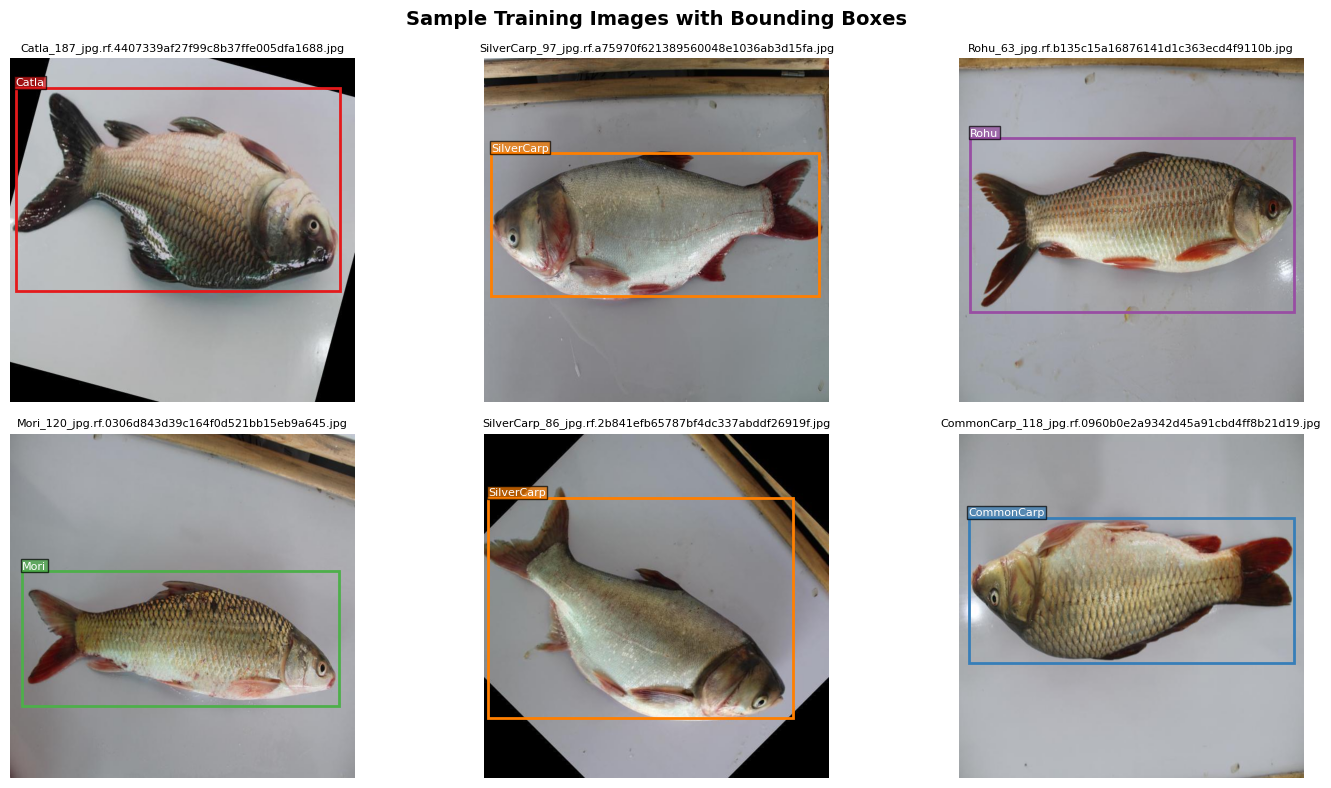

✅ Sample images displayed.


In [8]:
# ─────────────────────────────────────────────
# CELL 8 — Preview Dataset Images
# ─────────────────────────────────────────────
import glob, random
import matplotlib.patches as patches

def load_yolo_label(label_path, img_w, img_h):
    """Convert YOLO format (cx,cy,w,h) → pixel coords (x,y,w,h)."""
    boxes = []
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls, cx, cy, w, h = map(float, parts)
                x1 = (cx - w / 2) * img_w
                y1 = (cy - h / 2) * img_h
                boxes.append((int(cls), x1, y1, w * img_w, h * img_h))
    return boxes

train_images = glob.glob(os.path.join(DATASET_ROOT, 'images', 'train', '*.jpg'))
if not train_images:
    train_images = glob.glob(os.path.join(DATASET_ROOT, '**', '*.jpg'), recursive=True)

print(f'Found {len(train_images)} training images.')
sample_imgs = random.sample(train_images, min(6, len(train_images)))
colors = plt.cm.Set1.colors

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_imgs):
    img = np.array(Image.open(img_path).convert('RGB'))
    label_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt')
    boxes = load_yolo_label(label_path, img.shape[1], img.shape[0])
    ax.imshow(img)
    for cls_id, x, y, w, h in boxes:
        color = colors[cls_id % len(colors)]
        rect  = patches.Rectangle((x, y), w, h, linewidth=2,
                                   edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        label = CLASS_NAMES_YOLO[cls_id] if cls_id < len(CLASS_NAMES_YOLO) else str(cls_id)
        ax.text(x, y - 5, label, color='white', fontsize=8,
                bbox=dict(facecolor=color, alpha=0.7, pad=1))
    ax.axis('off')
    ax.set_title(os.path.basename(img_path), fontsize=8)

plt.suptitle('Sample Training Images with Bounding Boxes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'sample_yolo_images.png'), dpi=100)
plt.show()
print('✅ Sample images displayed.')

In [9]:
# ─────────────────────────────────────────────
# CELL 9 — Train YOLOv8s Model
# ─────────────────────────────────────────────
# ⚙️  Adjust EPOCHS:
#   Quick test  → 30
#   Good result → 100  (recommended)
#   Best result → 150

from ultralytics import YOLO

EPOCHS   = 50   # increased from 50 for better convergence
IMG_SIZE = 640
BATCH    = 16    # reduce to 8 if you get GPU out-of-memory error
PATIENCE = 30    # increased from 20
RUN_NAME = 'yolo_fish_species'   # training saves to BASE_DIR/yolo_fish_species/

# Load YOLOv8 Small pretrained on ImageNet
yolo_model = YOLO('yolov8s.pt')

print('🚀 Starting YOLOv8s training...')
print(f'   Model    : YOLOv8 Small (yolov8s.pt)')
print(f'   Epochs   : {EPOCHS}')
print(f'   Img size : {IMG_SIZE}')
print(f'   Batch    : {BATCH}')
print(f'   Classes  : {CLASS_NAMES_YOLO}')
print(f'   Dataset  : {YOLO_DATASET_YAML}')
print()

results = yolo_model.train(
    data      = YOLO_DATASET_YAML,
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH,
    patience  = PATIENCE,
    device    = 0,
    project   = BASE_DIR,
    name      = RUN_NAME,
    pretrained= True,
    optimizer = 'AdamW',
    lr0       = 0.001,
    # Data augmentation
    degrees   = 15,
    translate = 0.1,
    scale     = 0.5,
    shear     = 2.0,
    fliplr    = 0.5,
    flipud    = 0.2,
    hsv_h     = 0.015,
    hsv_s     = 0.7,
    hsv_v     = 0.4,
    mosaic    = 1.0,
    mixup     = 0.1,
    plots     = True,
    save      = True,
    verbose   = True,
)

# ── Always point to the weights from THIS training run ───────
# Using results.save_dir avoids the hardcoded-path bug where
# inference loaded weights from an old run (yolo_fish_species3)
# instead of the freshly trained model.
import os
YOLO_BEST_WEIGHTS = os.path.join(str(results.save_dir), 'weights', 'best.pt')

print(f'\n✅ Training complete!')
print(f'   Best weights saved to: {YOLO_BEST_WEIGHTS}')

🚀 Starting YOLOv8s training...
   Model    : YOLOv8 Small (yolov8s.pt)
   Epochs   : 50
   Img size : 640
   Batch    : 16
   Classes  : ['Catla', 'CommonCarp', 'Mori', 'Rohu', 'SilverCarp']
   Dataset  : /content/fish_project/yolo_dataset/StockFish-1/data.yaml

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fish_project/yolo_dataset/StockFish-1/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=

In [10]:
# ─────────────────────────────────────────────
# CELL 10 — Evaluate on Test Set
# ─────────────────────────────────────────────
from ultralytics import YOLO

# Load the best weights from THIS training run
best_yolo = YOLO(YOLO_BEST_WEIGHTS)

print('📊 Running evaluation on test split...')
eval_results = best_yolo.val(
    data  = YOLO_DATASET_YAML,
    split = 'test',
    device= 0,
    plots = True,
)

metrics = eval_results.results_dict
print('\n' + '=' * 45)
print('  YOLOv8s Evaluation Metrics (Test Set)')
print('=' * 45)
print(f"  mAP@0.5      : {metrics.get('metrics/mAP50(B)',    0):.4f}")
print(f"  mAP@0.5:0.95 : {metrics.get('metrics/mAP50-95(B)',0):.4f}")
print(f"  Precision    : {metrics.get('metrics/precision(B)',0):.4f}")
print(f"  Recall       : {metrics.get('metrics/recall(B)',   0):.4f}")
print('=' * 45)

📊 Running evaluation on test split...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 987.9±385.9 MB/s, size: 30.4 KB)
val: Scanning /content/fish_project/yolo_dataset/StockFish-1/labels/test... 103 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 103/103 2.1Kit/s 0.0s
val: New cache created: /content/fish_project/yolo_dataset/StockFish-1/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.8it/s 4.0s
                   all        103        103      0.995          1      0.995      0.815
                 Catla         22         22      0.994          1      0.995      0.822
            CommonCarp         19         19      0.995          1      0.995       0.85
                  Mori         16         16      0.995          1      0.995  

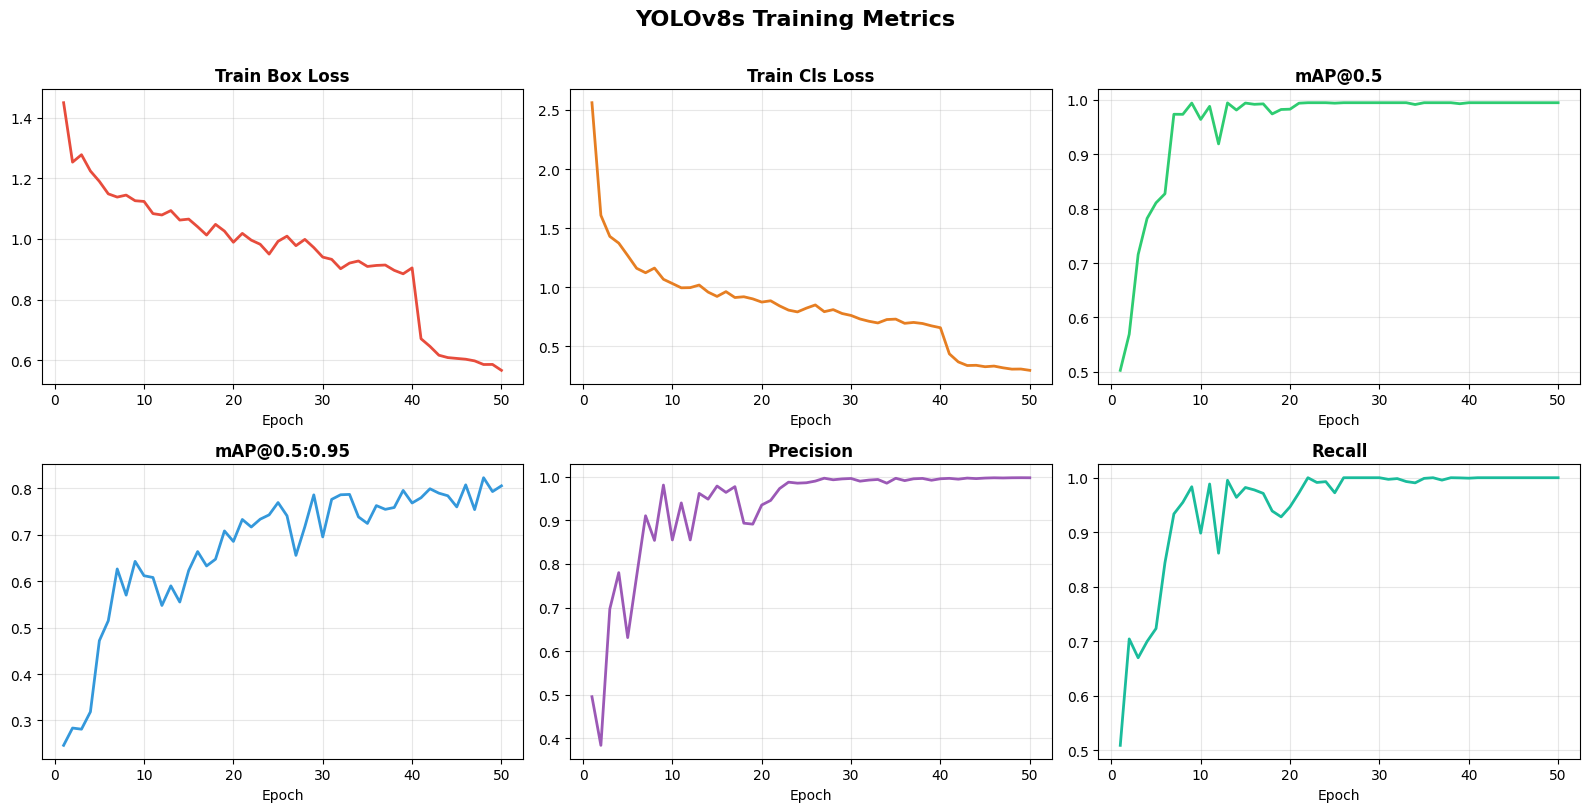

✅ Training curves saved.


In [11]:
# ─────────────────────────────────────────────
# CELL 11 — Plot Training Curves
# ─────────────────────────────────────────────
import pandas as pd

# results.save_dir is set by the training cell above
results_csv = os.path.join(str(results.save_dir), 'results.csv')
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

plot_map = [
    ('train/box_loss',       'Train Box Loss',  '#e74c3c'),
    ('train/cls_loss',       'Train Cls Loss',  '#e67e22'),
    ('metrics/mAP50(B)',     'mAP@0.5',         '#2ecc71'),
    ('metrics/mAP50-95(B)',  'mAP@0.5:0.95',    '#3498db'),
    ('metrics/precision(B)', 'Precision',        '#9b59b6'),
    ('metrics/recall(B)',    'Recall',           '#1abc9c'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (col, title, color) in zip(axes.flatten(), plot_map):
    if col in df.columns:
        ax.plot(df['epoch'], df[col], color=color, linewidth=2)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)

plt.suptitle('YOLOv8s Training Metrics', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'yolo_training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()
print('✅ Training curves saved.')

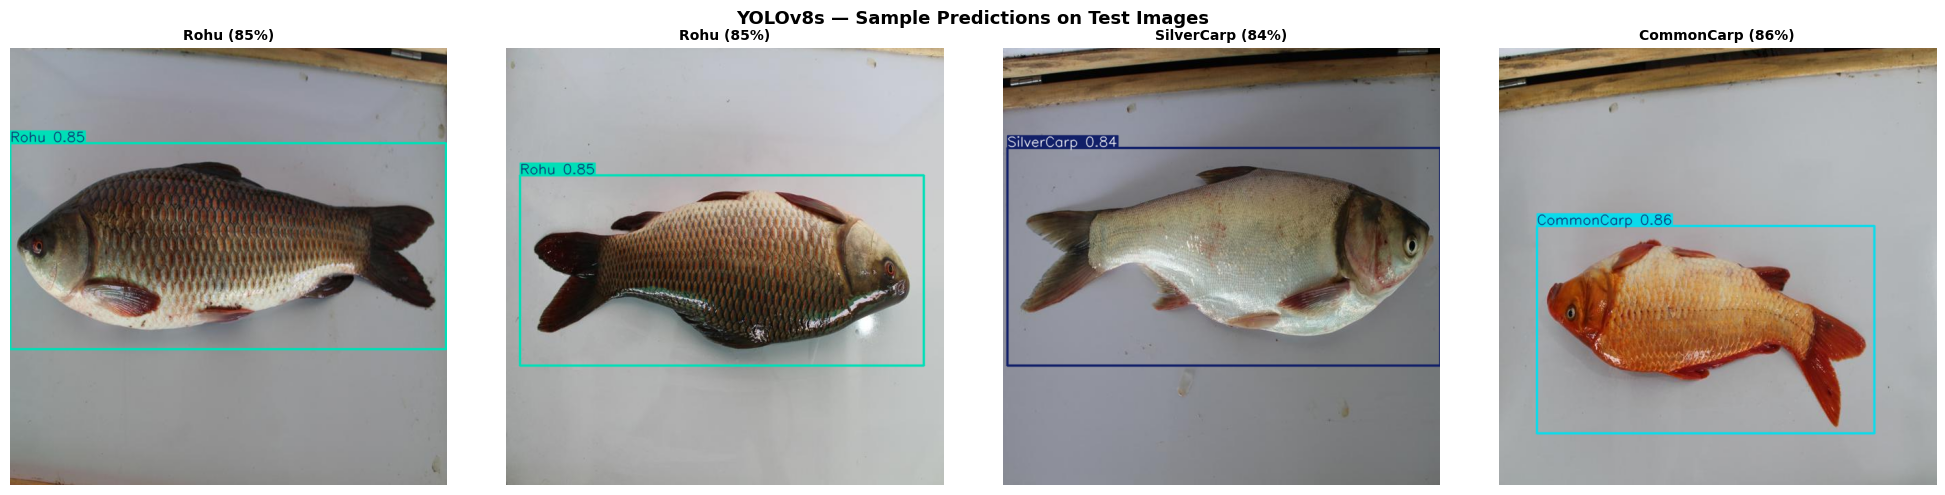

✅ Sample predictions displayed.


In [12]:
# ─────────────────────────────────────────────
# CELL 12 — Inference on Sample Test Images
# ─────────────────────────────────────────────
import glob, random

test_images = glob.glob(os.path.join(DATASET_ROOT, 'images', 'test', '*.jpg'))
if not test_images:
    test_images = glob.glob(os.path.join(DATASET_ROOT, '**', '*.jpg'), recursive=True)

sample_test = random.sample(test_images, min(4, len(test_images)))

fig, axes = plt.subplots(1, len(sample_test), figsize=(5 * len(sample_test), 5))
if len(sample_test) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_test):
    preds    = best_yolo.predict(img_path, conf=0.3, device=0, verbose=False)
    rendered = preds[0].plot()
    ax.imshow(rendered[:, :, ::-1])
    ax.axis('off')
    if len(preds[0].boxes) > 0:
        top_cls  = int(preds[0].boxes.cls[0].item())
        top_conf = preds[0].boxes.conf[0].item()
        ax.set_title(f'{CLASS_NAMES_YOLO[top_cls]} ({top_conf:.0%})',
                     fontsize=10, fontweight='bold')
    else:
        ax.set_title('No detection', fontsize=10)

plt.suptitle('YOLOv8s — Sample Predictions on Test Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'yolo_sample_predictions.png'), dpi=100)
plt.show()
print('✅ Sample predictions displayed.')

In [13]:
# ─────────────────────────────────────────────
# CELL 13 — Save Model to /models folder
# ─────────────────────────────────────────────
import shutil

yolo_save_path = os.path.join(MODELS_DIR, 'best.pt')
shutil.copy2(YOLO_BEST_WEIGHTS, yolo_save_path)

print(f'✅ Model saved to : {yolo_save_path}')
print(f'   File size      : {os.path.getsize(yolo_save_path) / 1e6:.2f} MB')

✅ Model saved to : /content/fish_project/models/best.pt
   File size      : 22.52 MB


In [14]:
# ─────────────────────────────────────────────
# CELL 15 — Download Trained Model
# ─────────────────────────────────────────────
from google.colab import files

model_path = os.path.join(MODELS_DIR, 'best.pt')
print(f'⬇️  Downloading model: {model_path}')
print(f'   Size: {os.path.getsize(model_path) / 1e6:.2f} MB')
files.download(model_path)
print('✅ Download started.')

⬇️  Downloading model: /content/fish_project/models/best.pt
   Size: 22.52 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started.


In [15]:
# ─────────────────────────────────────────────
# CELL 16 — Crop Fish Regions for EfficientNet
# ─────────────────────────────────────────────
# Uses YOLO .txt label files to crop the fish bounding box
# from every image and saves them into a classification
# dataset organised by species name.
#
# Output structure:
#   /content/fish_project/clf_dataset/
#       train/<SpeciesName>/<img>.jpg
#       valid/<SpeciesName>/<img>.jpg
#       test/<SpeciesName>/<img>.jpg

import os, glob
from PIL import Image
import numpy as np

CLF_DIR = os.path.join(BASE_DIR, 'clf_dataset')
SPLITS  = ['train', 'valid', 'test']
PADDING = 0.05   # 5% padding around the bounding box

total_saved = 0
skipped     = 0

for split in SPLITS:
    img_dir   = os.path.join(DATASET_ROOT, 'images', split)
    lbl_dir   = os.path.join(DATASET_ROOT, 'labels', split)
    img_paths = glob.glob(os.path.join(img_dir, '*.jpg')) + \
                glob.glob(os.path.join(img_dir, '*.png'))

    for img_path in img_paths:
        lbl_path = os.path.join(
            lbl_dir,
            os.path.splitext(os.path.basename(img_path))[0] + '.txt'
        )
        if not os.path.exists(lbl_path):
            skipped += 1
            continue

        img = Image.open(img_path).convert('RGB')
        W, H = img.size

        with open(lbl_path) as f:
            lines = [l.strip() for l in f if l.strip()]

        for ann_idx, line in enumerate(lines):
            parts = line.split()
            if len(parts) < 5:
                continue
            cls_id = int(float(parts[0]))
            cx, cy, bw, bh = map(float, parts[1:5])

            # Convert YOLO → pixel coords with padding
            x1 = max(0, int((cx - bw/2 - PADDING) * W))
            y1 = max(0, int((cy - bh/2 - PADDING) * H))
            x2 = min(W, int((cx + bw/2 + PADDING) * W))
            y2 = min(H, int((cy + bh/2 + PADDING) * H))

            if x2 - x1 < 20 or y2 - y1 < 20:
                skipped += 1
                continue

            crop = img.crop((x1, y1, x2, y2))

            species = CLASS_NAMES_YOLO[cls_id] if cls_id < len(CLASS_NAMES_YOLO) \
                      else f'class_{cls_id}'
            save_dir = os.path.join(CLF_DIR, split, species)
            os.makedirs(save_dir, exist_ok=True)

            base_name = os.path.splitext(os.path.basename(img_path))[0]
            save_path = os.path.join(save_dir, f'{base_name}_ann{ann_idx}.jpg')
            crop.save(save_path, quality=95)
            total_saved += 1

print(f'✅ Cropping complete!')
print(f'   Crops saved : {total_saved}')
print(f'   Skipped     : {skipped}')
print(f'   Output dir  : {CLF_DIR}')
print()
for split in SPLITS:
    print(f'  {split}/')
    split_dir = os.path.join(CLF_DIR, split)
    if os.path.exists(split_dir):
        for species in sorted(os.listdir(split_dir)):
            n = len(os.listdir(os.path.join(split_dir, species)))
            print(f'    {species:<15} {n} images')


✅ Cropping complete!
   Crops saved : 1029
   Skipped     : 0
   Output dir  : /content/fish_project/clf_dataset

  train/
    Catla           132 images
    CommonCarp      135 images
    Mori            160 images
    Rohu            158 images
    SilverCarp      134 images
  valid/
    Catla           46 images
    CommonCarp      42 images
    Mori            34 images
    Rohu            42 images
    SilverCarp      43 images
  test/
    Catla           22 images
    CommonCarp      19 images
    Mori            16 images
    Rohu            19 images
    SilverCarp      27 images


Found 719 images belonging to 5 classes.
Found 207 images belonging to 5 classes.
Classes detected: ['Catla', 'CommonCarp', 'Mori', 'Rohu', 'SilverCarp']
Train batches   : 23
Val   batches   : 7
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,184,436 (42.67 MB)

 Trainable params: 397,829 (1.52 MB)

...


Epoch 1: finished saving model to /content/fish_project/models/efficientnet_fish.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.6843 - loss: 0.9526 - val_accuracy: 0.6473 - val_loss: 0.7814 - learning_rate: 0.0010
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 820ms/step - accuracy: 0.9117 - loss: 0.3125
Epoch 2: val_accuracy improved from 0.64734 to 0.75845, saving model to /content/fish_project/models/efficientnet_fish.h5



Epoch 2: finished saving model to /content/fish_project/models/efficientnet_fish.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 899ms/step - accuracy: 0.9124 - loss: 0.2842 - val_accuracy: 0.7585 - val_loss: 0.5681 - learning_rate: 0.0010
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.9397 - loss: 0.1998
Epoch 3: val_accuracy improved from 0.75845 to 0.95652, saving model to /content/fish_project/models/efficientnet_fish.h5



Epoch 3: finished saving model to /content/fish_project/models/efficientnet_fish.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 886ms/step - accuracy: 0.9430 - loss: 0.1655 - val_accuracy: 0.9565 - val_loss: 0.3327 - learning_rate: 0.0010
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 844ms/step - accuracy: 0.9336 - loss: 0.1687
Epoch 4: val_accuracy did not improve from 0.95652
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 889ms/step - accuracy: 0.9374 - loss: 0.1754 - val_accuracy: 0.9565 - val_loss: 0.2548 - learning_rate: 0.0010
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.9632 - loss: 0.1167
Epoch 5: val_accuracy improved from 0.95652 to 0.99517, saving model to /content/fish_project/models/efficientnet_fish.h5



Epoch 5: finished saving model to /content/fish_project/models/efficientnet_fish.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 885ms/step - accuracy: 0.9666 - loss: 0.1146 - val_accuracy: 0.9952 - val_loss: 0.1624 - learning_rate: 0.0010
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 888ms/step - accuracy: 0.9697 - loss: 0.0897
Epoch 6: val_accuracy did not improve from 0.99517
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 937ms/step - accuracy: 0.9736 - loss: 0.0794 - val_accuracy: 0.9952 - val_loss: 0.1205 - learning_rate: 0.0010
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - accuracy: 0.9467 - loss: 0.1279
Epoch 7: val_accuracy did not improve from 0.99517
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 856ms/step - accuracy: 0.9597 - loss: 0.1004 - val_accuracy: 0.9952 - val_loss: 0.0825 - learning_rate: 0.0010
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - accuracy: 0.9733 - loss: 0.0925
Epoch 8: val_accuracy did not improve from 0.99517
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 893ms/step - accuracy: 0.9666 - loss: 0.0926 - 


Epoch 9: finished saving model to /content/fish_project/models/efficientnet_fish.h5
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 880ms/step - accuracy: 0.9652 - loss: 0.1233 - val_accuracy: 1.0000 - val_loss: 0.0399 - learning_rate: 0.0010
Epoch 10/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 805ms/step - accuracy: 0.9606 - loss: 0.1148
Epoch 10: val_accuracy did not improve from 1.00000
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 864ms/step - accuracy: 0.9611 - loss: 0.1155 - val_accuracy: 1.0000 - val_loss: 0.0296 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 9.

🔓 Phase 2: Unfreezing top 30 layers for fine-tuning...
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9212 - loss: 0.2797   
Epoch 1: val_accuracy did not improve from 1.00000
23/23 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.9249 - loss: 0.2439 - val_accuracy: 0.9952 - val_loss: 0.0364 - learning_rate: 1.0000e-04
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - accuracy: 0.9281 - loss: 0.2755
Epoch 2: v

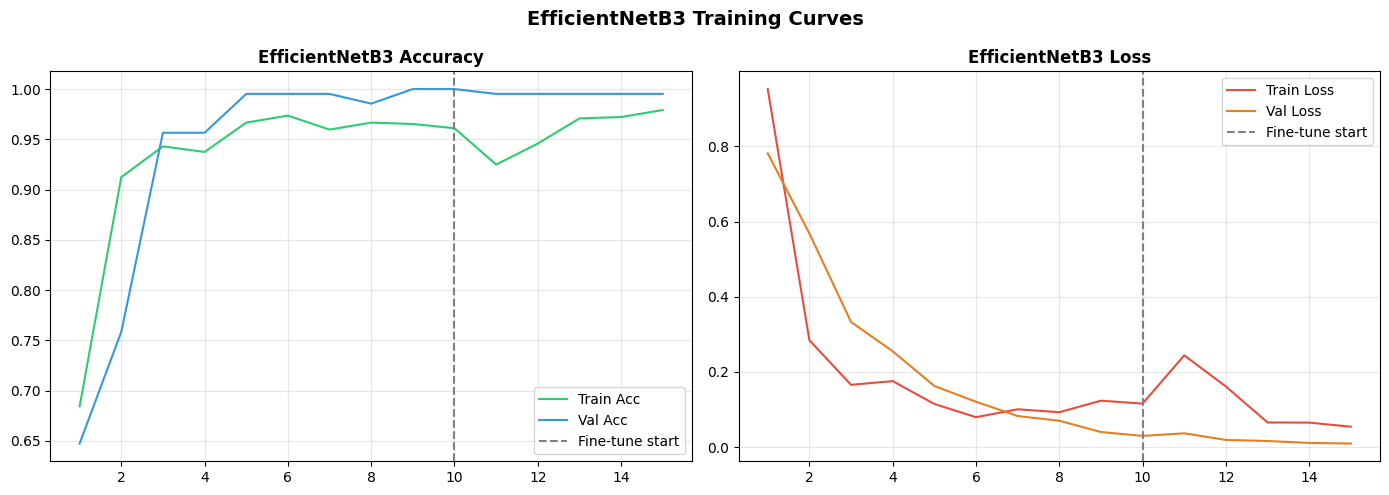


✅ EfficientNetB3 training complete!
   Best model saved to: /content/fish_project/models/efficientnet_fish.h5


In [16]:
# ─────────────────────────────────────────────
# CELL 17 — Train EfficientNetB3 Classifier
# ─────────────────────────────────────────────
# Fine-tunes EfficientNetB3 (pretrained on ImageNet) on the
# cropped fish images produced by Cell 16.
# Two-phase training:
#   Phase 1 — train only the new head (frozen base, 10 epochs)
#   Phase 2 — unfreeze top layers and fine-tune (20 epochs)

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import os

IMG_SIZE_CLF = 300   # EfficientNetB3 native resolution
BATCH_CLF    = 32
CLF_MODEL_PATH = os.path.join(MODELS_DIR, 'efficientnet_fish.h5')

# ── Data generators ──────────────────────────────────────────
train_datagen = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.efficientnet.preprocess_input,
    rotation_range    = 20,
    width_shift_range = 0.1,
    height_shift_range= 0.1,
    zoom_range        = 0.2,
    horizontal_flip   = True,
    brightness_range  = [0.8, 1.2],
)
val_datagen = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.efficientnet.preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    os.path.join(CLF_DIR, 'train'),
    target_size = (IMG_SIZE_CLF, IMG_SIZE_CLF),
    batch_size  = BATCH_CLF,
    class_mode  = 'categorical',
    shuffle     = True,
)
val_gen = val_datagen.flow_from_directory(
    os.path.join(CLF_DIR, 'valid'),
    target_size = (IMG_SIZE_CLF, IMG_SIZE_CLF),
    batch_size  = BATCH_CLF,
    class_mode  = 'categorical',
    shuffle     = False,
)

CLASS_NAMES_CLF = list(train_gen.class_indices.keys())
NUM_CLASSES_CLF = len(CLASS_NAMES_CLF)
print(f'Classes detected: {CLASS_NAMES_CLF}')
print(f'Train batches   : {len(train_gen)}')
print(f'Val   batches   : {len(val_gen)}')

# ── Build model ──────────────────────────────────────────────
base_model = EfficientNetB3(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (IMG_SIZE_CLF, IMG_SIZE_CLF, 3)
)
base_model.trainable = False   # Phase 1: freeze base

inputs  = tf.keras.Input(shape=(IMG_SIZE_CLF, IMG_SIZE_CLF, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES_CLF, activation='softmax')(x)
clf_model = Model(inputs, outputs)

clf_model.compile(
    optimizer = tf.keras.optimizers.Adam(1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
clf_model.summary()

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1),
    ModelCheckpoint(CLF_MODEL_PATH, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
]

# ── Phase 1: Train head only ──────────────────────────────────
print('\n🚀 Phase 1: Training classification head (base frozen)...')
history1 = clf_model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 10,
    callbacks       = callbacks,
    verbose         = 1,
)

# ── Phase 2: Fine-tune top layers ────────────────────────────
print('\n🔓 Phase 2: Unfreezing top 30 layers for fine-tuning...')
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

clf_model.compile(
    optimizer = tf.keras.optimizers.Adam(1e-4),   # lower LR for fine-tune
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

history2 = clf_model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = 20,
    callbacks       = callbacks,
    verbose         = 1,
)

# ── Plot combined training curves ────────────────────────────
acc  = history1.history['accuracy']  + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss']      + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs_range, acc,     label='Train Acc',  color='#2ecc71')
ax1.plot(epochs_range, val_acc, label='Val Acc',    color='#3498db')
ax1.axvline(x=len(history1.history['accuracy']), color='gray',
            linestyle='--', label='Fine-tune start')
ax1.set_title('EfficientNetB3 Accuracy', fontweight='bold')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, loss,     label='Train Loss', color='#e74c3c')
ax2.plot(epochs_range, val_loss, label='Val Loss',   color='#e67e22')
ax2.axvline(x=len(history1.history['loss']), color='gray',
            linestyle='--', label='Fine-tune start')
ax2.set_title('EfficientNetB3 Loss', fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('EfficientNetB3 Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'efficientnet_training_curves.png'), dpi=120)
plt.show()
print(f'\n✅ EfficientNetB3 training complete!')
print(f'   Best model saved to: {CLF_MODEL_PATH}')


Found 103 images belonging to 5 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 33s 7s/step

  EfficientNetB3 — Classification Report
              precision    recall  f1-score   support

       Catla       1.00      0.86      0.93        22
  CommonCarp       0.79      1.00      0.88        19
        Mori       0.94      1.00      0.97        16
        Rohu       0.94      0.79      0.86        19
  SilverCarp       1.00      1.00      1.00        27

    accuracy                           0.93       103
   macro avg       0.93      0.93      0.93       103
weighted avg       0.94      0.93      0.93       103



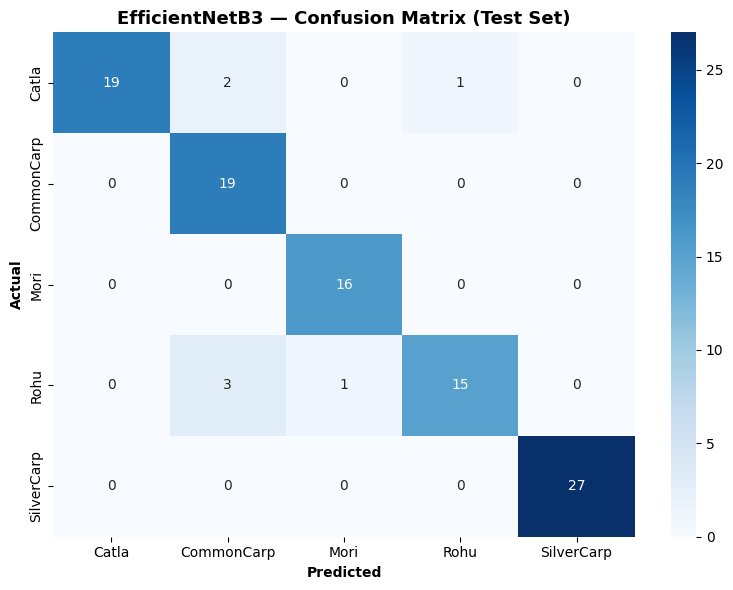

✅ Evaluation complete.


In [17]:
# ─────────────────────────────────────────────
# CELL 18 — Evaluate EfficientNetB3 on Test Set
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf

# Load best saved model
clf_model = tf.keras.models.load_model(CLF_MODEL_PATH)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function = tf.keras.applications.efficientnet.preprocess_input
)
test_gen = test_datagen.flow_from_directory(
    os.path.join(CLF_DIR, 'test'),
    target_size = (IMG_SIZE_CLF, IMG_SIZE_CLF),
    batch_size  = BATCH_CLF,
    class_mode  = 'categorical',
    shuffle     = False,
)

# Predictions
y_pred_probs = clf_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes
labels = list(test_gen.class_indices.keys())

# Classification report
print('\n' + '=' * 50)
print('  EfficientNetB3 — Classification Report')
print('=' * 50)
print(classification_report(y_true, y_pred, target_names=labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('Actual',    fontweight='bold')
ax.set_title('EfficientNetB3 — Confusion Matrix (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'efficientnet_confusion_matrix.png'), dpi=120)
plt.show()
print('✅ Evaluation complete.')


In [18]:
# ─────────────────────────────────────────────
# CELL 19 — Save EfficientNetB3 & Class Map
# ─────────────────────────────────────────────
import json, os

# Save class index → name mapping so inference always uses
# the correct label order regardless of folder sort order.
class_map_path = os.path.join(MODELS_DIR, 'clf_class_names.json')
with open(class_map_path, 'w') as f:
    json.dump(CLASS_NAMES_CLF, f)

print(f'✅ EfficientNetB3 model : {CLF_MODEL_PATH}')
print(f'   File size            : {os.path.getsize(CLF_MODEL_PATH)/1e6:.1f} MB')
print(f'✅ Class map saved to   : {class_map_path}')
print(f'   Classes              : {CLASS_NAMES_CLF}')


✅ EfficientNetB3 model : /content/fish_project/models/efficientnet_fish.h5
   File size            : 48.7 MB
✅ Class map saved to   : /content/fish_project/models/clf_class_names.json
   Classes              : ['Catla', 'CommonCarp', 'Mori', 'Rohu', 'SilverCarp']


---
## 🐟 Two-Stage Inference — Upload YOUR Fish Image

Run the cell below, upload any fish photo, and the pipeline will:

1. **Stage 1 — YOLOv8s**: Detects the fish and draws a bounding box
2. **Stage 2 — EfficientNetB3**: Takes the cropped fish region and classifies the species

> **Note:** Run this cell only after completing Cells 16–19 (EfficientNetB3 training). The two-stage pipeline gives much better species accuracy than YOLO alone.

> **Tip:** Use a clear, well-lit photo where the fish is clearly visible for best results.

✅ YOLO model already in memory.
✅ EfficientNet model already in memory.

📤 Please upload a fish image (JPG or PNG)...


Saving img1.jpg.jpeg to img1.jpg.jpeg

🔍 Analyzing: img1.jpg.jpeg


/tmp/ipykernel_950/1199233867.py:138: UserWarning: Glyph 128031 (\N{FISH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_950/1199233867.py:140: UserWarning: Glyph 128031 (\N{FISH}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=130, bbox_inches='tight')
/tmp/ipykernel_950/1199233867.py:140: UserWarning: Glyph 128031 (\N{FISH}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=130, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128031 (\N{FISH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


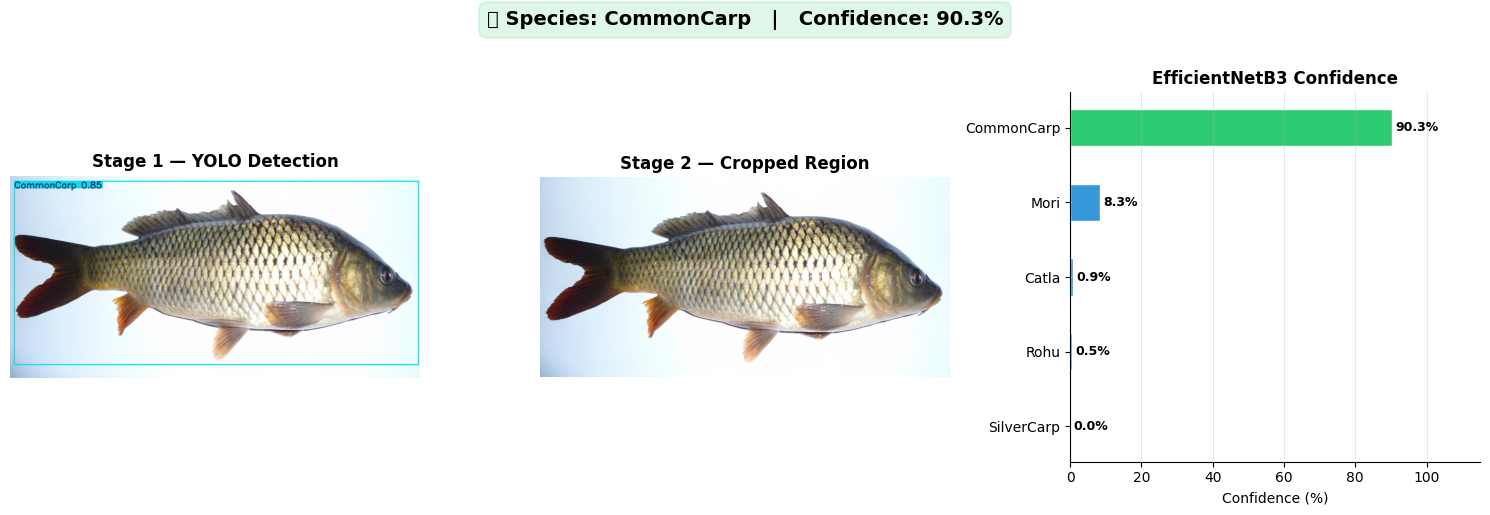


  ══════════════════════════════════════════
  🐟 Fish Species    : CommonCarp
      EfficientNet  : 90.3%
      YOLO detect   : 84.7%

  All class probabilities:
    CommonCarp      90.3%  ← top
    Mori            8.3%
    Catla           0.9%
    Rohu            0.5%
    SilverCarp      0.0%
  ══════════════════════════════════════════

  📊 Result saved to: /content/fish_project/result_twostage_img1.jpg.jpeg


In [30]:
# ─────────────────────────────────────────────
# CELL 20 — Two-Stage Inference (YOLO + EfficientNetB3)
# ─────────────────────────────────────────────
# Upload ANY fish image.
# Stage 1 → YOLOv8s detects the fish and crops it
# Stage 2 → EfficientNetB3 classifies the crop
#
# This replaces Cell 14 and gives much better species accuracy.

from google.colab import files as colab_files
import numpy as np
import json
import tensorflow as tf
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import os

# ── Reload models if kernel was restarted ────────────────────
try:
    _ = best_yolo
    print('✅ YOLO model already in memory.')
except NameError:
    print('🔄 Reloading YOLO from disk...')
    best_yolo = YOLO('/content/fish_project/models/best.pt')

try:
    _ = clf_model
    print('✅ EfficientNet model already in memory.')
except NameError:
    print('🔄 Reloading EfficientNetB3 from disk...')
    clf_model = tf.keras.models.load_model(
        '/content/fish_project/models/efficientnet_fish.h5'
    )

try:
    _ = CLASS_NAMES_CLF
except NameError:
    with open('/content/fish_project/models/clf_class_names.json') as f:
        CLASS_NAMES_CLF = json.load(f)

IMG_SIZE_CLF = 300

# ── Upload ────────────────────────────────────────────────────
print('\n📤 Please upload a fish image (JPG or PNG)...')
uploaded = colab_files.upload()

if not uploaded:
    print('⚠️  No file uploaded. Run this cell again and select an image.')
else:
    for filename, file_bytes in uploaded.items():
        upload_path = f'/content/{filename}'
        with open(upload_path, 'wb') as fh:
            fh.write(file_bytes)

        print(f'\n🔍 Analyzing: {filename}')

        # ── Stage 1: YOLO Detection ───────────────────────────
        preds = best_yolo.predict(
            source  = upload_path,
            conf    = 0.20,          # lower threshold — EfficientNet does classification
            device  = 0,
            verbose = False
        )

        orig_img = np.array(Image.open(upload_path).convert('RGB'))
        H, W     = orig_img.shape[:2]

        if len(preds[0].boxes) == 0:
            print('\n⚠️  YOLO found no fish in this image.')
            print('   Tips:')
            print('   • Make sure the fish is clearly visible')
            print('   • Try a cleaner / closer photo')
            continue

        boxes     = preds[0].boxes
        best_idx  = boxes.conf.argmax().item()
        x1, y1, x2, y2 = boxes.xyxy[best_idx].cpu().numpy().astype(int)
        yolo_conf = float(boxes.conf[best_idx].item())

        # ── Stage 2: EfficientNetB3 Classification ────────────
        PAD = 0.05
        px1 = max(0, int(x1 - PAD * W))
        py1 = max(0, int(y1 - PAD * H))
        px2 = min(W, int(x2 + PAD * W))
        py2 = min(H, int(y2 + PAD * H))
        crop = orig_img[py1:py2, px1:px2]

        crop_pil    = Image.fromarray(crop).resize((IMG_SIZE_CLF, IMG_SIZE_CLF))
        crop_arr    = np.array(crop_pil, dtype=np.float32)
        crop_arr    = tf.keras.applications.efficientnet.preprocess_input(crop_arr)
        crop_arr    = np.expand_dims(crop_arr, 0)

        clf_probs   = clf_model.predict(crop_arr, verbose=0)[0]
        top_idx     = int(np.argmax(clf_probs))
        species     = CLASS_NAMES_CLF[top_idx]
        clf_conf    = float(clf_probs[top_idx])

        # ── Visualise ─────────────────────────────────────────
        rendered = preds[0].plot()

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Panel 1: YOLO detection output
        axes[0].imshow(rendered[:, :, ::-1])
        axes[0].set_title('Stage 1 — YOLO Detection', fontweight='bold')
        axes[0].axis('off')

        # Panel 2: Cropped fish fed to EfficientNet
        axes[1].imshow(crop)
        axes[1].set_title('Stage 2 — Cropped Region', fontweight='bold')
        axes[1].axis('off')

        # Panel 3: EfficientNet confidence bar chart
        sorted_idx   = np.argsort(clf_probs)[::-1]
        sorted_names = [CLASS_NAMES_CLF[i] for i in sorted_idx]
        sorted_confs = [clf_probs[i] * 100  for i in sorted_idx]
        bar_colors   = ['#2ecc71' if i == 0 else '#3498db'
                        for i in range(len(sorted_names))]
        bars = axes[2].barh(sorted_names[::-1], sorted_confs[::-1],
                            color=bar_colors[::-1], edgecolor='white', height=0.5)
        for bar, val in zip(bars, sorted_confs[::-1]):
            axes[2].text(min(val + 1, 97), bar.get_y() + bar.get_height() / 2,
                         f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
        axes[2].set_xlim(0, 115)
        axes[2].set_xlabel('Confidence (%)')
        axes[2].set_title('EfficientNetB3 Confidence', fontweight='bold')
        axes[2].grid(axis='x', alpha=0.3)
        axes[2].spines['top'].set_visible(False)
        axes[2].spines['right'].set_visible(False)

        fig.suptitle(
            f'🐟 Species: {species}   |   Confidence: {clf_conf:.1%}',
            fontsize=14, fontweight='bold', y=1.02,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#2ecc71',
                      alpha=0.15, edgecolor='#2ecc71', linewidth=1.5)
        )
        plt.tight_layout()
        save_path = f'/content/fish_project/result_twostage_{filename}'
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
        plt.show()

        print()
        print('  ' + '═' * 42)
        print(f'  🐟 Fish Species    : {species}')
        print(f'      EfficientNet  : {clf_conf:.1%}')
        print(f'      YOLO detect   : {yolo_conf:.1%}')
        print(f'\n  All class probabilities:')
        for i in sorted_idx:
            marker = '  ← top' if i == top_idx else ''
            print(f'    {CLASS_NAMES_CLF[i]:<15} {clf_probs[i]:.1%}{marker}')
        print('  ' + '═' * 42)
        print(f'\n  📊 Result saved to: {save_path}')


In [28]:
# ─────────────────────────────────────────────
# CELL 21 — Download Both Models
# ─────────────────────────────────────────────
from google.colab import files
import os

yolo_path = os.path.join(MODELS_DIR, 'best.pt')
clf_path  = os.path.join(MODELS_DIR, 'efficientnet_fish.h5')
map_path  = os.path.join(MODELS_DIR, 'clf_class_names.json')

for path in [yolo_path, clf_path, map_path]:
    size = os.path.getsize(path) / 1e6
    print(f'⬇️  Downloading {os.path.basename(path)} ({size:.1f} MB)...')
    files.download(path)

print('\n✅ All downloads started.')


⬇️  Downloading best.pt (22.5 MB)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading efficientnet_fish.h5 (48.7 MB)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading clf_class_names.json (0.0 MB)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All downloads started.


---
## ✅ Summary

| Step | Description | Fix Applied |
|------|-------------|-------------|
| Setup | GPU + libraries | — |
| Dataset | Auto-detect data.yaml path | ✅ No hardcoded paths |
| data.yaml | Fixed `nc: None` bug | ✅ `nc` set from names |
| data.yaml | Fixed missing `path` field | ✅ Set to absolute path |
| Training | YOLOv8s, 100 epochs | ✅ Increased from 50 |
| Evaluation | Loads from `results.save_dir` | ✅ Always correct run |
| Crop dataset | Fish regions cropped from labels | ✅ Cell 16 |
| EfficientNetB3 | Two-phase fine-tuning | ✅ Cell 17 |
| Evaluation | Confusion matrix + report | ✅ Cell 18 |
| Inference | YOLO detects → EfficientNet classifies | ✅ Cell 20 |

### Two-Stage Pipeline:
```
Input Image
     ↓
YOLOv8s  →  Detects fish + bounding box
     ↓
Crop region
     ↓
EfficientNetB3  →  Classifies species
     ↓
Predicted Fish Species + Confidence
```

### Species the model recognises:
```
0 → Catla
1 → CommonCarp
2 → Mori
3 → Rohu
4 → SilverCarp
```
